# Feature Engineering
This notebook verifies our calculated features such as Expected Field Goal% (xFG%), Expected Points Per Shot (xPPS), and Instantaneous Shot Threat (IST)

## Import Functions


In [1]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path
# Add project root to path for imports
ROOT = Path.cwd().parent  
sys.path.append(str(ROOT))
from src.data_io.maps import load_maps_npz
from src.viz.court import plot_players_by_name

## Test quality maps and all season shots

In [2]:
# 1. Test the Parquet output
shots_df = pd.read_parquet("../data/demo/processed/all_season_shots.parquet")

print("--- SHOTS DATA TEST ---")
print(f"Total shots processed: {len(shots_df)}")
print(f"Columns: {list(shots_df.columns)}")

# Check if our specific ML features generated correctly
assert 'xFG_offense' in shots_df.columns, "Missing xFG feature!"
assert 'xPPS_offense' in shots_df.columns, "Missing xPPS feature!"
print("✅ Shot features verified successfully.")


# 2. Test Spatial Maps output
maps, meta = load_maps_npz("../data/demo/processed/maps_1ft_xpps.npz")

print("\n--- SPATIAL MAPS TEST ---")

# Check if our specific ML features generated correctly, should be (x, 50, 47)
print(f"Map Array Shape: {maps['quality'].shape}")
print("✅ Spatial maps loaded successfully.")

--- SHOTS DATA TEST ---
Total shots processed: 207630
Columns: ['GAME_ID', 'SHOT_EVENT_ID', 'PERIOD', 'game_clock', 'PLAYER_ID', 'TEAM_ID', 'x_ft', 'y_ft', 'xFG_offense', 'xPPS_offense', 'SHOT_MADE_FLAG']
✅ Shot features verified successfully.

--- SPATIAL MAPS TEST ---
Map Array Shape: (393, 50, 47)
✅ Spatial maps loaded successfully.


## Test Player Map

[*] Scaling colormap to fixed maximum: 1.500 xPPS


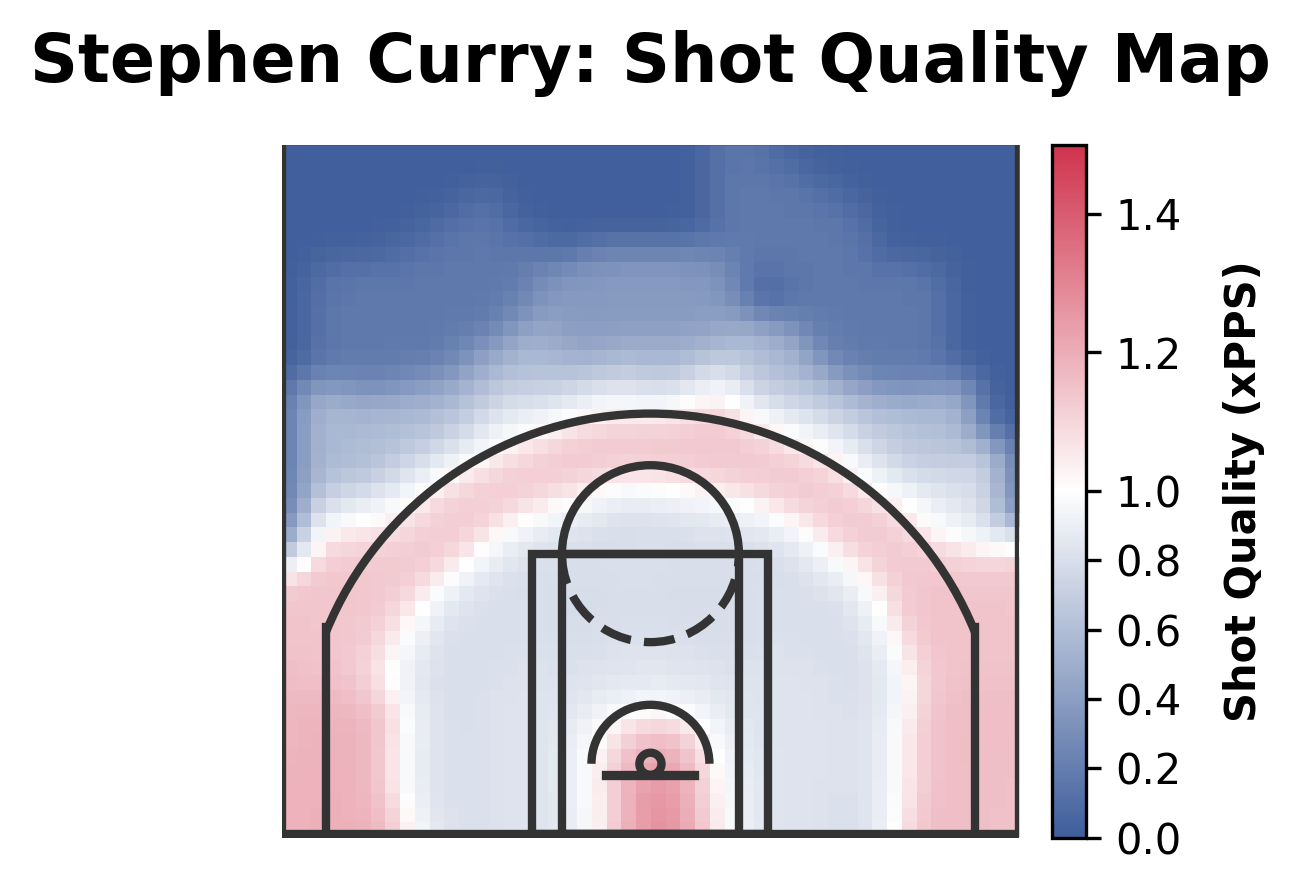

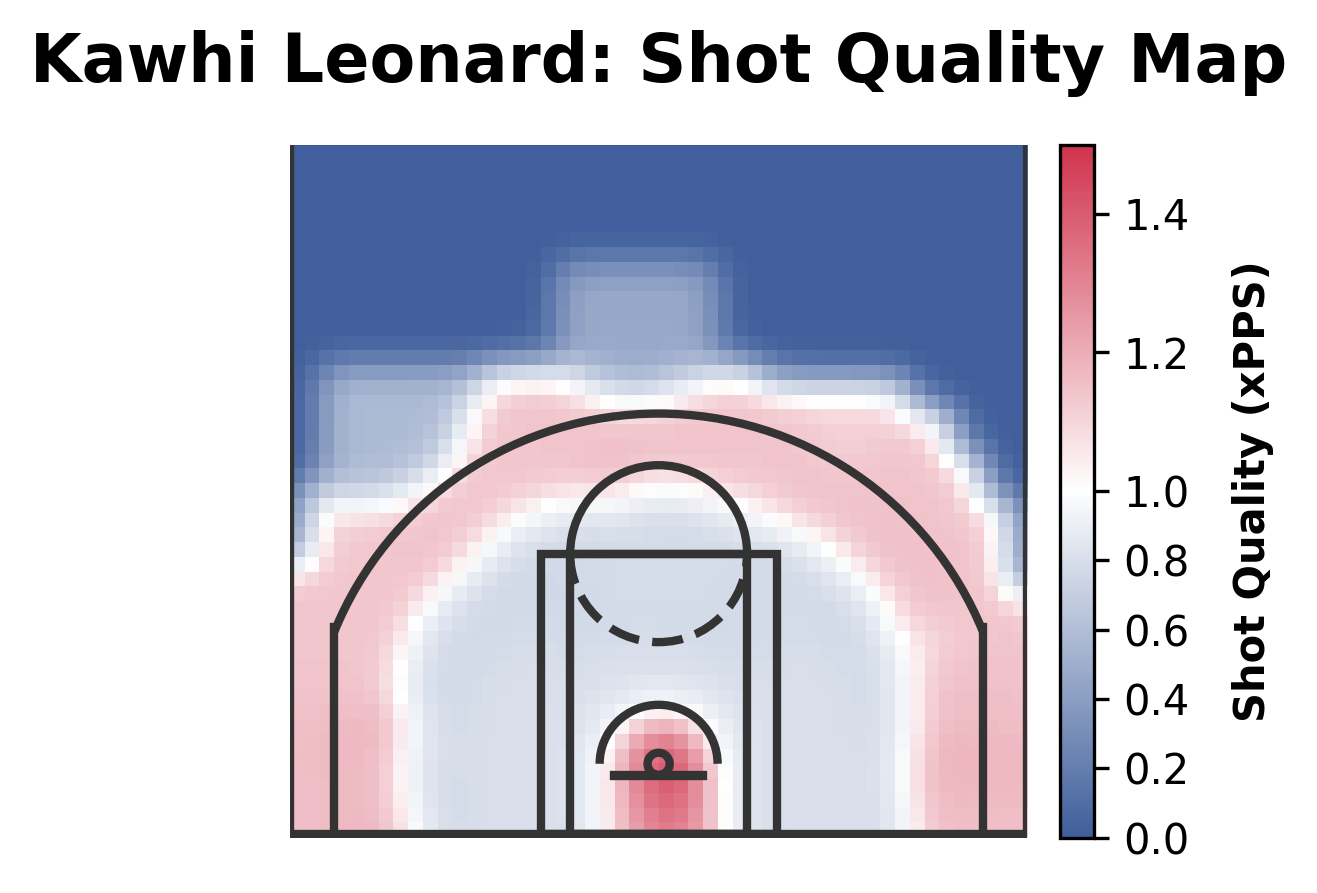

In [3]:
players = ['Stephen Curry', 'Kawhi Leonard']
plot_players_by_name(players, maps, meta)